# Topic Analysis on JGH PREM — SageMaker v2.x

Performs **LDA topic modelling** on the lemmatised YAKE keywords produced by `lem_yake_sagemaker.ipynb`.

| | Value |
|---|---|
| **Input parquet** | `s3://sagemaker-us-west-2-493644444178/spark-nlp/redaction/jgh-msss-prem/redacted_output/lem_ana/part-00000-4df57da9-3c5b-4f9e-9b73-6965eb92de63-c000.snappy.parquet` |
| **Key columns** | `lemmatized_keywords_aspects`, `lemmatized_keywords_suggestions` |

**Pipeline overview:**

| Step | Component | Purpose |
|---|---|---|
| Basic | `DocumentAssembler → Tokenizer → Normalizer → LemmatizerModel → StopWordsCleaner → PerceptronModel → NGramGenerator → Finisher` | Unigrams + n-grams + POS |
| Extended | `DocumentAssembler → Tokenizer → NGramGenerator → Finisher` | POS n-grams for filtering |
| Filter | `filter_pos`, `filter_pos_combs` | Keep `JJ NN NNS VB VBP` only |
| Model | `CountVectorizer → IDF → LDA` | Topic extraction |
| Vis | Word cloud, bar chart, word count distribution | Topic visualisation |

## 1. Environment Setup

In [1]:
import subprocess, sys, os

java_check = subprocess.run(["java", "-version"], capture_output=True)
if java_check.returncode != 0:
    print("Java not found — installing default-jdk ...")
    subprocess.run(["apt-get", "update", "-qq"], check=True)
    subprocess.run(["apt-get", "install", "-y", "-qq", "default-jdk"], check=True)
    print("Java installed.")
else:
    print("Java already available:", java_check.stderr.decode().split('\n')[0])

java_home_candidates = [
    "/usr/lib/jvm/java-11-openjdk-amd64",
    "/usr/lib/jvm/java-11-amazon-corretto",
    "/usr/lib/jvm/java-8-openjdk-amd64",
    "/usr/lib/jvm/java-8-amazon-corretto",
]
for candidate in java_home_candidates:
    if os.path.isdir(candidate):
        os.environ["JAVA_HOME"] = candidate
        break
else:
    result = subprocess.run(
        ["java", "-XshowSettings:all", "-version"],
        capture_output=True, text=True
    )
    for line in result.stderr.splitlines():
        if "java.home" in line:
            java_home = line.split("=")[1].strip()
            if java_home.endswith("/jre"):
                java_home = java_home[:-4]
            os.environ["JAVA_HOME"] = java_home
            break

print("JAVA_HOME:", os.environ.get("JAVA_HOME", "NOT SET"))

Java already available: openjdk version "11.0.30" 2026-01-20
JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64


In [2]:
!pip install -q \
    "sagemaker>=2.0,<3.0" \
    "pyspark>=3.3,<3.6" \
    "boto3" \
    "nltk" \
    "wordcloud" \
    "stylecloud" \
    "matplotlib" \
    "seaborn" \
    "pandas<2.0"

print("All packages installed.")


All packages installed.


## 2. SageMaker v2.x Session Setup

In [3]:
import boto3
import sagemaker
from sagemaker import get_execution_role

boto_session = boto3.Session()
sm_session   = sagemaker.Session(boto_session=boto_session)

try:
    role = get_execution_role(sagemaker_session=sm_session)
except Exception:
    role = os.environ.get("SAGEMAKER_ROLE", "<YOUR_SAGEMAKER_EXECUTION_ROLE_ARN>")
    print("WARNING: Could not auto-detect execution role. Set SAGEMAKER_ROLE env var.")

region  = boto_session.region_name or sm_session.boto_region_name
account = boto3.client("sts").get_caller_identity()["Account"]

BUCKET     = "sagemaker-us-west-2-493644444178"
INPUT_KEY  = ("spark-nlp/redaction/jgh-msss-prem/redacted_output/lem_ana/"
              "part-00000-4df57da9-3c5b-4f9e-9b73-6965eb92de63-c000.snappy.parquet")
INPUT_S3   = f"s3://{BUCKET}/{INPUT_KEY}"

print(f"SageMaker SDK version : {sagemaker.__version__}")
print(f"Region                : {region}")
print(f"Execution role ARN    : {role}")
print(f"Input  S3             : {INPUT_S3}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/cjen/.config/sagemaker/config.yaml
SageMaker SDK version : 2.253.1
Region                : us-west-2
Execution role ARN    : arn:aws:iam::493644444178:role/aws-reserved/sso.amazonaws.com/ap-southeast-1/AWSReservedSSO_AWSAdministratorAccess_e93147afb9349dfd
Input  S3             : s3://sagemaker-us-west-2-493644444178/spark-nlp/redaction/jgh-msss-prem/redacted_output/lem_ana/part-00000-4df57da9-3c5b-4f9e-9b73-6965eb92de63-c000.snappy.parquet


## 3. Import Libraries

In [4]:
import json
import os
import re
import math
import random
import warnings

import numpy as np
import pandas as pd

from wordcloud import WordCloud, ImageColorGenerator, STOPWORDS
import stylecloud

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
sns.set_style("darkgrid")

# pyspark.ml only — Spark-NLP runs inside the SageMaker Processing Job containers
from pyspark.sql import SparkSession, Row
from pyspark.sql import types as T
from pyspark.sql import functions as F
from pyspark.sql.functions import (
    udf, col, size, trim, monotonically_increasing_id, concat_ws, concat, explode,
)
from pyspark.ml.clustering import LDA
from pyspark.ml.linalg import DenseVector
from pyspark.ml.feature import CountVectorizer, IDF

warnings.filterwarnings("ignore")
pd.options.display.max_colwidth = None
pd.options.display.float_format = "${:,.3f}".format

colors = sns.color_palette("PuBuGn")
cols   = [color for name, color in mcolors.TABLEAU_COLORS.items()] * 4

print("Libraries imported.")


Libraries imported.


## 4. Start Local PySpark Session

Plain PySpark only — **Spark-NLP is not started locally**.
It runs exclusively inside the SageMaker Processing Job containers.


In [5]:
# Plain PySpark session — Spark-NLP is NOT started locally.
# It runs only inside the SageMaker Processing Job containers.
spark = (
    SparkSession.builder
    .appName("TopAna-LDA")
    .config("spark.driver.memory", "16G")
    .config("spark.driver.maxResultSize", "2000M")
    .getOrCreate()
)
spark


26/03/30 07:22:26 WARN Utils: Your hostname, MindyJen1008 resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/03/30 07:22:26 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/30 07:22:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 5. Configure Active Column

Set which lemmatised keyword column to model.
This value is passed as an argument to `basic_pipeline.py` inside the SageMaker container.


In [6]:
# Options: 'aspects_text'  |  'suggestions_text'
ACTIVE_COL = "aspects_text"

print(f"Active column: {ACTIVE_COL}")


Active column: aspects_text


## 8. Basic NLP Pipeline

```
pipeline = Pipeline()
    .setStages([documentAssembler,
                tokenizer,
                normalizer,
                lemmatizer,
                stopwords_cleaner,
                pos_tagger,
                ngrammer,
                finisher])
```

### 8.1 Resolve SageMaker-Assumable IAM Role

In [7]:
import boto3, json, time

iam          = boto3.client('iam')
SM_ROLE_NAME = 'SageMakerExecutionRole-SparkNLP'

TRUST_POLICY = json.dumps({
    'Version': '2012-10-17',
    'Statement': [{
        'Effect'   : 'Allow',
        'Principal': {'Service': 'sagemaker.amazonaws.com'},
        'Action'   : 'sts:AssumeRole',
    }],
})

try:
    sm_role = iam.get_role(RoleName=SM_ROLE_NAME)['Role']['Arn']
    print(f'Reusing existing role: {sm_role}')
except iam.exceptions.NoSuchEntityException:
    print(f"Creating '{SM_ROLE_NAME}' ...")
    sm_role = iam.create_role(
        RoleName                 = SM_ROLE_NAME,
        AssumeRolePolicyDocument = TRUST_POLICY,
        Description              = 'SageMaker execution role for Spark-NLP processing jobs',
    )['Role']['Arn']
    for policy_arn in [
        'arn:aws:iam::aws:policy/AmazonSageMakerFullAccess',
        'arn:aws:iam::aws:policy/AmazonS3FullAccess',
    ]:
        iam.attach_role_policy(RoleName=SM_ROLE_NAME, PolicyArn=policy_arn)
        print(f'  Attached {policy_arn}')
    print('Waiting 15 s for IAM propagation ...')
    time.sleep(15)

print(f'\nsm_role = {sm_role}')


Reusing existing role: arn:aws:iam::493644444178:role/SageMakerExecutionRole-SparkNLP

sm_role = arn:aws:iam::493644444178:role/SageMakerExecutionRole-SparkNLP


### 8.2 Verify / Re-Stage Spark-NLP Assembly JAR

In [8]:
import urllib.request
from sagemaker.s3 import S3Uploader

NLP_VER         = '5.5.3'
jar_name        = f'spark-nlp-assembly-{NLP_VER}.jar'
jar_prefix      = 'spark-nlp/key-ana'   # reuse JAR already staged by lem job
sparknlp_jar_s3 = f's3://{BUCKET}/{jar_prefix}/jars/{jar_name}'

s3_client = boto3.client('s3')
jar_key   = f'{jar_prefix}/jars/{jar_name}'
try:
    s3_client.head_object(Bucket=BUCKET, Key=jar_key)
    print(f'JAR already staged: {sparknlp_jar_s3}')
except s3_client.exceptions.ClientError:
    print('JAR not found — downloading and staging ...')
    local = f'/tmp/{jar_name}'
    for url in [
        f'https://s3.amazonaws.com/auxdata.johnsnowlabs.com/public/jars/{jar_name}',
        f'https://repo1.maven.org/maven2/com/johnsnowlabs/nlp/spark-nlp-assembly_2.12/{NLP_VER}/spark-nlp-assembly_2.12-{NLP_VER}.jar',
    ]:
        try:
            print(f'  Trying {url}')
            urllib.request.urlretrieve(url, local)
            with open(local, 'rb') as f:
                if f.read(2) != b'PK': raise RuntimeError('Not a valid JAR')
            S3Uploader.upload(local, f's3://{BUCKET}/{jar_prefix}/jars', sagemaker_session=sm_session)
            print(f'  Staged at {sparknlp_jar_s3}')
            break
        except Exception as e:
            print(f'  x {e}')
    else:
        raise RuntimeError('Could not obtain the Spark-NLP assembly JAR.')

print(f'\nsparknlp_jar_s3 = {sparknlp_jar_s3}')


JAR already staged: s3://sagemaker-us-west-2-493644444178/spark-nlp/key-ana/jars/spark-nlp-assembly-5.5.3.jar

sparknlp_jar_s3 = s3://sagemaker-us-west-2-493644444178/spark-nlp/key-ana/jars/spark-nlp-assembly-5.5.3.jar


### 8.3 Submit basic_pipeline.py Processing Job

`PySparkProcessor` provisions `ml.m5.4xlarge`, runs `basic_pipeline.py` inside
the managed Spark-NLP container, and **automatically terminates** when done.

| | Value |
|---|---|
| **Input** | `lem_ana/` (lemmatised parquet) |
| **Output** | `top_ana/basic_ana/` |
| **Arg** | `aspects_text` (change to `suggestions_text` to switch column) |

In [9]:
from sagemaker.spark.processing import PySparkProcessor
from sagemaker.processing import ProcessingInput, ProcessingOutput

BASIC_INPUT_S3  = f's3://{BUCKET}/spark-nlp/redaction/jgh-msss-prem/redacted_output/lem_ana/'
BASIC_OUTPUT_S3 = f's3://{BUCKET}/spark-nlp/redaction/jgh-msss-prem/redacted_output/top_ana/basic_ana/'

SPARK_CONFIG = [{
    'Classification': 'spark-defaults',
    'Properties': {
        'spark.serializer'                : 'org.apache.spark.serializer.KryoSerializer',
        'spark.kryoserializer.buffer.max' : '2000M',
        'spark.driver.memory'             : '16G',
        'spark.driver.maxResultSize'      : '4000M',
        'spark.executor.memory'           : '20G',
        'spark.executor.memoryOverhead'   : '4G',
    },
}]

basic_processor = PySparkProcessor(
    base_job_name          = 'spark-nlp-basic-pipeline',
    framework_version      = '3.3',
    role                   = sm_role,
    instance_count         = 1,
    instance_type          = 'ml.m5.4xlarge',
    max_runtime_in_seconds = 3600,
    sagemaker_session      = sm_session,
)

basic_processor.run(
    submit_app    = 'basic_pipeline.py',
    submit_jars   = [sparknlp_jar_s3],
    arguments     = [ACTIVE_COL],          # aspects_text or suggestions_text
    configuration = SPARK_CONFIG,
    inputs  = [ProcessingInput(
        source      = BASIC_INPUT_S3,
        destination = '/opt/ml/processing/input',
    )],
    outputs = [ProcessingOutput(
        source      = '/opt/ml/processing/output/data',
        destination = BASIC_OUTPUT_S3,
    )],
    logs = True,
    wait = True,
)

print(f'\nBasic pipeline job complete. Output: {BASIC_OUTPUT_S3}')


INFO:sagemaker:Creating processing-job with name spark-nlp-basic-pipeline-2026-03-30-14-26-48-150


............03-30 14:28 smspark.cli  INFO     Parsing arguments. argv: ['/usr/local/bin/smspark-submit', '--jars', 's3://sagemaker-us-west-2-493644444178/spark-nlp/key-ana/jars/spark-nlp-assembly-5.5.3.jar', '/opt/ml/processing/input/code/basic_pipeline.py', 'aspects_text']
03-30 14:28 smspark.cli  INFO     Raw spark options before processing: {'jars': 's3://sagemaker-us-west-2-493644444178/spark-nlp/key-ana/jars/spark-nlp-assembly-5.5.3.jar', 'class_': None, 'py_files': None, 'files': None, 'verbose': False}
03-30 14:28 smspark.cli  INFO     App and app arguments: ['/opt/ml/processing/input/code/basic_pipeline.py', 'aspects_text']
03-30 14:28 smspark.cli  INFO     Rendered spark options: {'jars': 's3://sagemaker-us-west-2-493644444178/spark-nlp/key-ana/jars/spark-nlp-assembly-5.5.3.jar', 'class_': None, 'py_files': None, 'files': None, 'verbose': False}
03-30 14:28 smspark.cli  INFO     Initializing processing job.
03-30 14:28 smspark-submit INFO     {'current_host': 'algo-1', 'curren

### 8.4 Fetch CloudWatch Logs — basic_pipeline

In [10]:
logs      = boto3.client('logs', region_name=region)
job_name  = basic_processor.latest_job.job_name
log_group = '/aws/sagemaker/ProcessingJobs'
print(f'Job      : {job_name}')
print(f'LogGroup : {log_group}\n')

for attempt in range(10):
    resp    = logs.describe_log_streams(logGroupName=log_group, logStreamNamePrefix=job_name)
    streams = resp.get('logStreams', [])
    if streams: break
    print(f'  Waiting for log streams (attempt {attempt+1}/10) ...')
    time.sleep(6)

for stream in streams:
    print(f"\n{'='*60}\nStream: {stream['logStreamName']}\n{'='*60}")
    for event in logs.get_log_events(
        logGroupName=log_group, logStreamName=stream['logStreamName'], startFromHead=True
    )['events']:
        print(event['message'])


Job      : spark-nlp-basic-pipeline-2026-03-30-14-26-48-150
LogGroup : /aws/sagemaker/ProcessingJobs


Stream: spark-nlp-basic-pipeline-2026-03-30-14-26-48-150/algo-1-1774880843
03-30 14:28 smspark.cli  INFO     Parsing arguments. argv: ['/usr/local/bin/smspark-submit', '--jars', 's3://sagemaker-us-west-2-493644444178/spark-nlp/key-ana/jars/spark-nlp-assembly-5.5.3.jar', '/opt/ml/processing/input/code/basic_pipeline.py', 'aspects_text']
03-30 14:28 smspark.cli  INFO     Raw spark options before processing: {'jars': 's3://sagemaker-us-west-2-493644444178/spark-nlp/key-ana/jars/spark-nlp-assembly-5.5.3.jar', 'class_': None, 'py_files': None, 'files': None, 'verbose': False}
03-30 14:28 smspark.cli  INFO     App and app arguments: ['/opt/ml/processing/input/code/basic_pipeline.py', 'aspects_text']
03-30 14:28 smspark.cli  INFO     Rendered spark options: {'jars': 's3://sagemaker-us-west-2-493644444178/spark-nlp/key-ana/jars/spark-nlp-assembly-5.5.3.jar', 'class_': None, 'py_files': None, 

## 9. Extended NLP Pipeline

Generate POS-tag n-grams that mirror the word n-grams, so we can filter n-gram
combinations based on valid POS-tag sequences.

```
pos_pipeline = Pipeline()
    .setStages([pos_documentAssembler,
                pos_tokenizer,
                pos_ngrammer,
                pos_finisher])
```

### 9.1 Submit pos_pipeline.py Processing Job

Reads `basic_ana/` output, runs the extended POS pipeline + filtering,
and writes `filtered_unigrams`, `filtered_ngrams`, `final` to `pos_ana/`.

In [11]:
POS_INPUT_S3  = BASIC_OUTPUT_S3
POS_OUTPUT_S3 = f's3://{BUCKET}/spark-nlp/redaction/jgh-msss-prem/redacted_output/top_ana/pos_ana/'

pos_processor = PySparkProcessor(
    base_job_name          = 'spark-nlp-pos-pipeline',
    framework_version      = '3.3',
    role                   = sm_role,
    instance_count         = 1,
    instance_type          = 'ml.m5.4xlarge',
    max_runtime_in_seconds = 3600,
    sagemaker_session      = sm_session,
)

pos_processor.run(
    submit_app    = 'pos_pipeline.py',
    submit_jars   = [sparknlp_jar_s3],
    configuration = SPARK_CONFIG,
    inputs  = [ProcessingInput(
        source      = POS_INPUT_S3,
        destination = '/opt/ml/processing/input',
    )],
    outputs = [ProcessingOutput(
        source      = '/opt/ml/processing/output/data',
        destination = POS_OUTPUT_S3,
    )],
    logs = True,
    wait = True,
)

print(f'\nPOS pipeline job complete. Output: {POS_OUTPUT_S3}')


INFO:sagemaker:Creating processing-job with name spark-nlp-pos-pipeline-2026-03-30-14-36-53-577


............03-30 14:38 smspark.cli  INFO     Parsing arguments. argv: ['/usr/local/bin/smspark-submit', '--jars', 's3://sagemaker-us-west-2-493644444178/spark-nlp/key-ana/jars/spark-nlp-assembly-5.5.3.jar', '/opt/ml/processing/input/code/pos_pipeline.py']
03-30 14:38 smspark.cli  INFO     Raw spark options before processing: {'jars': 's3://sagemaker-us-west-2-493644444178/spark-nlp/key-ana/jars/spark-nlp-assembly-5.5.3.jar', 'class_': None, 'py_files': None, 'files': None, 'verbose': False}
03-30 14:38 smspark.cli  INFO     App and app arguments: ['/opt/ml/processing/input/code/pos_pipeline.py']
03-30 14:38 smspark.cli  INFO     Rendered spark options: {'jars': 's3://sagemaker-us-west-2-493644444178/spark-nlp/key-ana/jars/spark-nlp-assembly-5.5.3.jar', 'class_': None, 'py_files': None, 'files': None, 'verbose': False}
03-30 14:38 smspark.cli  INFO     Initializing processing job.
03-30 14:38 smspark-submit INFO     {'current_host': 'algo-1', 'current_instance_type': 'ml.m5.4xlarge', '

### 9.2 Fetch CloudWatch Logs — pos_pipeline

In [12]:
job_name = pos_processor.latest_job.job_name
print(f'Job      : {job_name}')
print(f'LogGroup : {log_group}\n')

for attempt in range(10):
    resp    = logs.describe_log_streams(logGroupName=log_group, logStreamNamePrefix=job_name)
    streams = resp.get('logStreams', [])
    if streams: break
    print(f'  Waiting for log streams (attempt {attempt+1}/10) ...')
    time.sleep(6)

for stream in streams:
    print(f"\n{'='*60}\nStream: {stream['logStreamName']}\n{'='*60}")
    for event in logs.get_log_events(
        logGroupName=log_group, logStreamName=stream['logStreamName'], startFromHead=True
    )['events']:
        print(event['message'])


Job      : spark-nlp-pos-pipeline-2026-03-30-14-36-53-577
LogGroup : /aws/sagemaker/ProcessingJobs


Stream: spark-nlp-pos-pipeline-2026-03-30-14-36-53-577/algo-1-1774881448
03-30 14:38 smspark.cli  INFO     Parsing arguments. argv: ['/usr/local/bin/smspark-submit', '--jars', 's3://sagemaker-us-west-2-493644444178/spark-nlp/key-ana/jars/spark-nlp-assembly-5.5.3.jar', '/opt/ml/processing/input/code/pos_pipeline.py']
03-30 14:38 smspark.cli  INFO     Raw spark options before processing: {'jars': 's3://sagemaker-us-west-2-493644444178/spark-nlp/key-ana/jars/spark-nlp-assembly-5.5.3.jar', 'class_': None, 'py_files': None, 'files': None, 'verbose': False}
03-30 14:38 smspark.cli  INFO     App and app arguments: ['/opt/ml/processing/input/code/pos_pipeline.py']
03-30 14:38 smspark.cli  INFO     Rendered spark options: {'jars': 's3://sagemaker-us-west-2-493644444178/spark-nlp/key-ana/jars/spark-nlp-assembly-5.5.3.jar', 'class_': None, 'py_files': None, 'files': None, 'verbose': False}
03-30 1

### 9.3 Download pos_pipeline Output and Read into Local Spark

LDA and visualisation run locally in this notebook.
We download the pos_pipeline parquet from S3 and load it into the
local Spark session (started in Section 4).

In [13]:
import io

pos_prefix = POS_OUTPUT_S3.replace(f's3://{BUCKET}/', '').rstrip('/') + '/'
paginator  = boto3.client('s3').get_paginator('list_objects_v2')
pos_files  = [
    obj['Key']
    for page in paginator.paginate(Bucket=BUCKET, Prefix=pos_prefix)
    for obj in page.get('Contents', [])
    if obj['Key'].endswith('.parquet')
]
print(f'Parquet files in pos_ana output: {len(pos_files)}')
for k in pos_files:
    print(f'  s3://{BUCKET}/{k}')

LOCAL_POS_DIR = '/tmp/pos_ana_output'
os.makedirs(LOCAL_POS_DIR, exist_ok=True)
s3_client = boto3.client('s3', region_name=region)
for key in pos_files:
    fname = os.path.basename(key)
    s3_client.download_file(BUCKET, key, os.path.join(LOCAL_POS_DIR, fname))
    print(f'  Downloaded {fname}')

processed_review = spark.read.parquet(f'file://{LOCAL_POS_DIR}')
print(f'\nLoaded into Spark: {processed_review.count()} rows, columns: {processed_review.columns}')
processed_review.select('filtered_unigrams', 'filtered_ngrams', 'final').show(5, truncate=80)


Parquet files in pos_ana output: 3
  s3://sagemaker-us-west-2-493644444178/spark-nlp/redaction/jgh-msss-prem/redacted_output/top_ana/pos_ana/part-00000-bffedea1-a2e1-4d5a-abb4-e245ad53f407-c000.snappy.parquet
  s3://sagemaker-us-west-2-493644444178/spark-nlp/redaction/jgh-msss-prem/redacted_output/top_ana/pos_ana/part-00000-c44a7123-3d1f-47c0-af5d-0b4be898a900-c000.snappy.parquet
  s3://sagemaker-us-west-2-493644444178/spark-nlp/redaction/jgh-msss-prem/redacted_output/top_ana/pos_ana/part-00000-f2ef3556-674a-4329-b0c9-2040347ee18f-c000.snappy.parquet
  Downloaded part-00000-bffedea1-a2e1-4d5a-abb4-e245ad53f407-c000.snappy.parquet
  Downloaded part-00000-c44a7123-3d1f-47c0-af5d-0b4be898a900-c000.snappy.parquet
  Downloaded part-00000-f2ef3556-674a-4329-b0c9-2040347ee18f-c000.snappy.parquet



Loaded into Spark: 32718 rows, columns: ['Unnamed: 0', 'Date de complétion', 'Évaluation', "Aspects positifs de l'expérience globale", 'redacted_aspects', "Suggestions d'amélioration de l'expérience globale", 'redacted_suggestions', 'yake_keywords_aspects', 'yake_keywords_suggestions', 'lemmatized_keywords_aspects', 'lemmatized_keywords_suggestions', 'aspects_text', 'suggestions_text', 'finished_unigrams', 'finished_ngrams', 'finished_pos', 'finished_pos_ngrams', 'filtered_unigrams', 'filtered_ngrams', 'final']
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                               filtered_unigrams|                                                                 filtered_ngrams|                                                                          

## 10. LDA Topic Modelling — SageMaker Processing Job

Reads `pos_ana/` output, runs CountVectorizer → IDF → LDA, and writes
`topic_words`, `topic_cloud`, `term_frequency`, `topic_scores`, `vocab.json`
to `top_ana/lda_ana/` on S3.

In [14]:
LDA_INPUT_S3  = POS_OUTPUT_S3
LDA_OUTPUT_S3 = f's3://{BUCKET}/spark-nlp/redaction/jgh-msss-prem/redacted_output/top_ana/lda_ana/'

lda_processor = PySparkProcessor(
    base_job_name          = 'spark-nlp-lda-pipeline',
    framework_version      = '3.3',
    role                   = sm_role,
    instance_count         = 1,
    instance_type          = 'ml.m5.4xlarge',
    max_runtime_in_seconds = 3600,
    sagemaker_session      = sm_session,
)

lda_processor.run(
    submit_app    = 'lda_pipeline.py',
    arguments     = [ACTIVE_COL, '20', '10'],   # text_col, num_topics, max_iter
    configuration = SPARK_CONFIG,
    inputs  = [ProcessingInput(
        source      = LDA_INPUT_S3,
        destination = '/opt/ml/processing/input',
    )],
    outputs = [ProcessingOutput(
        source      = '/opt/ml/processing/output/data',
        destination = LDA_OUTPUT_S3,
    )],
    logs = True,
    wait = True,
)

print(f'\nLDA job complete. Output: {LDA_OUTPUT_S3}')


INFO:sagemaker:Creating processing-job with name spark-nlp-lda-pipeline-2026-03-30-14-50-55-197


............03-30 14:52 smspark.cli  INFO     Parsing arguments. argv: ['/usr/local/bin/smspark-submit', '/opt/ml/processing/input/code/lda_pipeline.py', 'aspects_text', '20', '10']
03-30 14:52 smspark.cli  INFO     Raw spark options before processing: {'class_': None, 'jars': None, 'py_files': None, 'files': None, 'verbose': False}
03-30 14:52 smspark.cli  INFO     App and app arguments: ['/opt/ml/processing/input/code/lda_pipeline.py', 'aspects_text', '20', '10']
03-30 14:52 smspark.cli  INFO     Rendered spark options: {'class_': None, 'jars': None, 'py_files': None, 'files': None, 'verbose': False}
03-30 14:52 smspark.cli  INFO     Initializing processing job.
03-30 14:52 smspark-submit INFO     {'current_host': 'algo-1', 'current_instance_type': 'ml.m5.4xlarge', 'current_group_name': 'homogeneousCluster', 'hosts': ['algo-1'], 'instance_groups': [{'instance_group_name': 'homogeneousCluster', 'instance_type': 'ml.m5.4xlarge', 'hosts': ['algo-1']}], 'network_interface_name': 'eth0', 

### 10.1 Fetch CloudWatch Logs — lda_pipeline

In [15]:
job_name = lda_processor.latest_job.job_name
print(f'Job      : {job_name}')
print(f'LogGroup : {log_group}\n')

for attempt in range(10):
    resp    = logs.describe_log_streams(logGroupName=log_group, logStreamNamePrefix=job_name)
    streams = resp.get('logStreams', [])
    if streams: break
    print(f'  Waiting for log streams (attempt {attempt+1}/10) ...')
    time.sleep(6)

for stream in streams:
    print(f"\n{'='*60}\nStream: {stream['logStreamName']}\n{'='*60}")
    for event in logs.get_log_events(
        logGroupName=log_group, logStreamName=stream['logStreamName'], startFromHead=True
    )['events']:
        print(event['message'])


Job      : spark-nlp-lda-pipeline-2026-03-30-14-50-55-197
LogGroup : /aws/sagemaker/ProcessingJobs


Stream: spark-nlp-lda-pipeline-2026-03-30-14-50-55-197/algo-1-1774882287
03-30 14:52 smspark.cli  INFO     Parsing arguments. argv: ['/usr/local/bin/smspark-submit', '/opt/ml/processing/input/code/lda_pipeline.py', 'aspects_text', '20', '10']
03-30 14:52 smspark.cli  INFO     Raw spark options before processing: {'class_': None, 'jars': None, 'py_files': None, 'files': None, 'verbose': False}
03-30 14:52 smspark.cli  INFO     App and app arguments: ['/opt/ml/processing/input/code/lda_pipeline.py', 'aspects_text', '20', '10']
03-30 14:52 smspark.cli  INFO     Rendered spark options: {'class_': None, 'jars': None, 'py_files': None, 'files': None, 'verbose': False}
03-30 14:52 smspark.cli  INFO     Initializing processing job.
03-30 14:52 smspark-submit INFO     {'current_host': 'algo-1', 'current_instance_type': 'ml.m5.4xlarge', 'current_group_name': 'homogeneousCluster', 'hosts': ['algo-

### 10.2 Download LDA Outputs from S3

Read all output parquets into the local PySpark session for visualisation.

In [16]:
import json as _json

lda_prefix = LDA_OUTPUT_S3.replace(f's3://{BUCKET}/', '').rstrip('/') + '/'
paginator  = boto3.client('s3').get_paginator('list_objects_v2')
lda_objects = [
    obj['Key']
    for page in paginator.paginate(Bucket=BUCKET, Prefix=lda_prefix)
    for obj in page.get('Contents', [])
]
print(f'LDA output objects: {len(lda_objects)}')
for k in lda_objects: print(f'  s3://{BUCKET}/{k}')

LOCAL_LDA_DIR = '/tmp/lda_ana_output'
import shutil
if os.path.exists(LOCAL_LDA_DIR): shutil.rmtree(LOCAL_LDA_DIR)
os.makedirs(LOCAL_LDA_DIR, exist_ok=True)

s3_client = boto3.client('s3', region_name=region)
for key in lda_objects:
    rel  = key[len(lda_prefix):]
    dest = os.path.join(LOCAL_LDA_DIR, rel)
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    s3_client.download_file(BUCKET, key, dest)
    print(f'  Downloaded {rel}')

# Read each subdirectory into local Spark
termFrequencyDf             = spark.read.parquet(f'file://{LOCAL_LDA_DIR}/term_frequency')
topic_cloud_df              = spark.read.parquet(f'file://{LOCAL_LDA_DIR}/topic_cloud')
topic_scores_with_counts_df = spark.read.parquet(f'file://{LOCAL_LDA_DIR}/topic_scores')
topic_words_df              = spark.read.parquet(f'file://{LOCAL_LDA_DIR}/topic_words')

with open(os.path.join(LOCAL_LDA_DIR, 'vocab.json')) as vf:
    vocab = _json.load(vf)

print(f'\ntermFrequencyDf             : {termFrequencyDf.count()} rows')
print(f'topic_cloud_df              : {topic_cloud_df.count()} rows')
print(f'topic_scores_with_counts_df : {topic_scores_with_counts_df.count()} rows')
print(f'topic_words_df              : {topic_words_df.count()} rows')
print(f'vocab size                  : {len(vocab)}')
topic_words_df.select('topic', 'topicWords').show(5, truncate=120)


LDA output objects: 17
  s3://sagemaker-us-west-2-493644444178/spark-nlp/redaction/jgh-msss-prem/redacted_output/top_ana/lda_ana/term_frequency/._SUCCESS.crc
  s3://sagemaker-us-west-2-493644444178/spark-nlp/redaction/jgh-msss-prem/redacted_output/top_ana/lda_ana/term_frequency/.part-00000-a8d66f1e-ec6b-4df2-92e6-a533a83a5ff4-c000.snappy.parquet.crc
  s3://sagemaker-us-west-2-493644444178/spark-nlp/redaction/jgh-msss-prem/redacted_output/top_ana/lda_ana/term_frequency/_SUCCESS
  s3://sagemaker-us-west-2-493644444178/spark-nlp/redaction/jgh-msss-prem/redacted_output/top_ana/lda_ana/term_frequency/part-00000-a8d66f1e-ec6b-4df2-92e6-a533a83a5ff4-c000.snappy.parquet
  s3://sagemaker-us-west-2-493644444178/spark-nlp/redaction/jgh-msss-prem/redacted_output/top_ana/lda_ana/topic_cloud/._SUCCESS.crc
  s3://sagemaker-us-west-2-493644444178/spark-nlp/redaction/jgh-msss-prem/redacted_output/top_ana/lda_ana/topic_cloud/.part-00000-0381b9a1-a0c2-4a8b-a328-8e65dd3859a6-c000.snappy.parquet.crc
  s3:/

## 13. Visualization

### 13.1 Topic Frequency Bar Chart

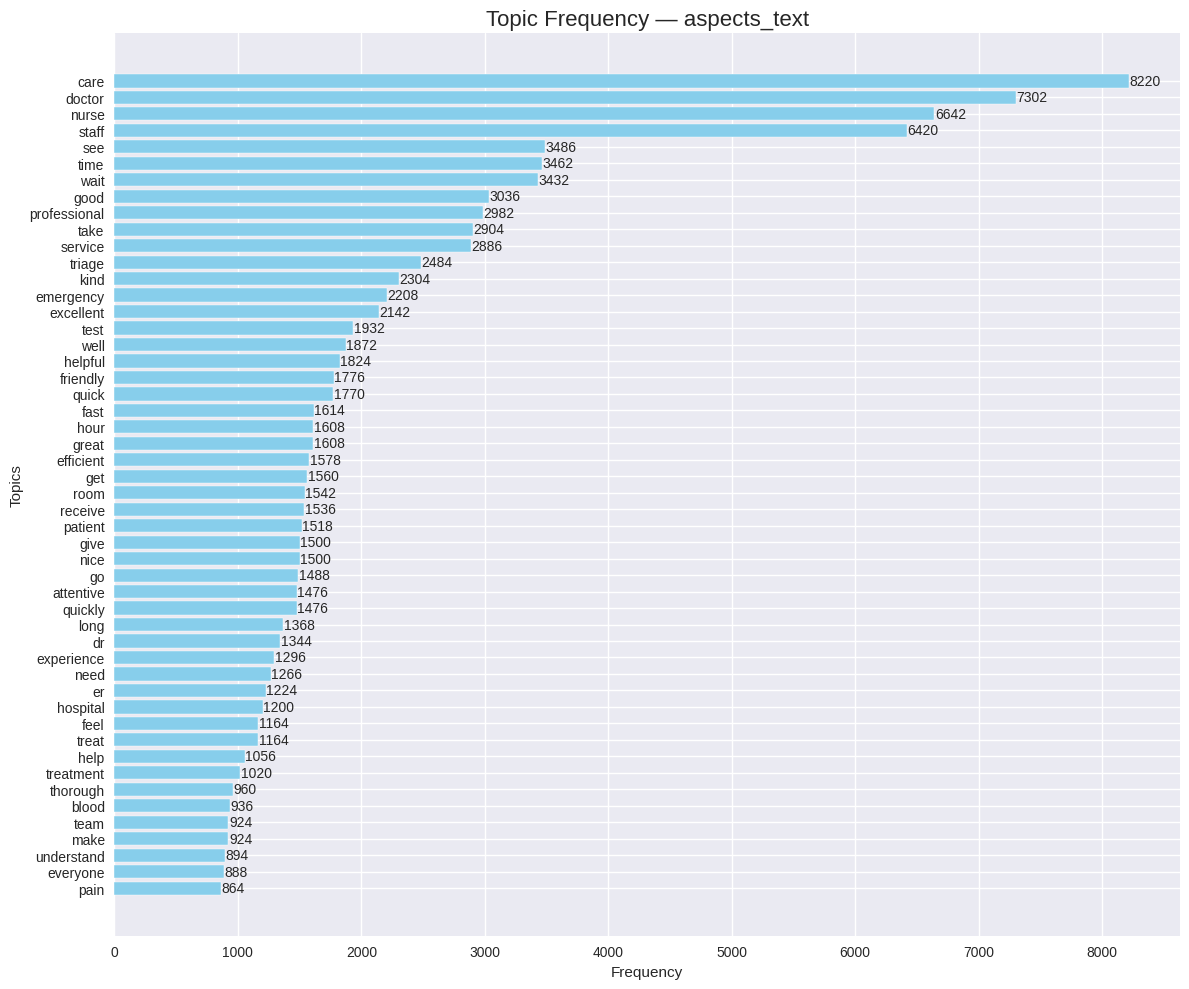

In [17]:
no_topics      = 50
topic_count_df = termFrequencyDf.toPandas()
topic_draw     = topic_count_df[:no_topics].sort_values(by="frequency", ascending=True)

plt.style.use("seaborn-v0_8")
plt.figure(figsize=(12, 10))
plt.barh(topic_draw["term"], topic_draw["frequency"], color="skyblue")
plt.xlabel("Frequency")
plt.ylabel("Topics")
plt.title(f"Topic Frequency — {ACTIVE_COL}", fontsize=16)
for index, value in enumerate(topic_draw["frequency"]):
    plt.text(value + 5, index, str(value), va="center")
plt.tight_layout()
plt.show()


### 13.2 Topic Word Cloud

In [18]:
def plot_cloud_by_topic(cloudDf, n_topics):
    """Plot word cloud of top N words in each topic."""
    cloud_df = cloudDf.toPandas()
    cloud = WordCloud(
        background_color="white",
        width=2500,
        height=1800,
        max_words=10,
        colormap="tab10",
        color_func=lambda *args, **kwargs: cols[i],
        prefer_horizontal=1.0,
    )
    fig, axes = plt.subplots(
        4, int(n_topics / 4),
        figsize=(n_topics * 0.95, n_topics - 4),
        sharex=True, sharey=True,
    )
    for i, ax in enumerate(axes.flatten()):
        fig.add_subplot(ax)
        cloud_df_sub  = cloud_df.loc[cloud_df.topic == i]
        topic_words   = dict(zip(cloud_df_sub.term, cloud_df_sub.termWeights))
        cloud.generate_from_frequencies(topic_words, max_font_size=500)
        plt.gca().imshow(cloud)
        plt.gca().set_title(
            "Topic " + str(i + 1),
            fontdict=dict(size=32, color=cols[i])
        )
        plt.gca().axis("off")
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.axis("off")
    plt.margins(x=0, y=0)
    plt.tight_layout()
    plt.show()

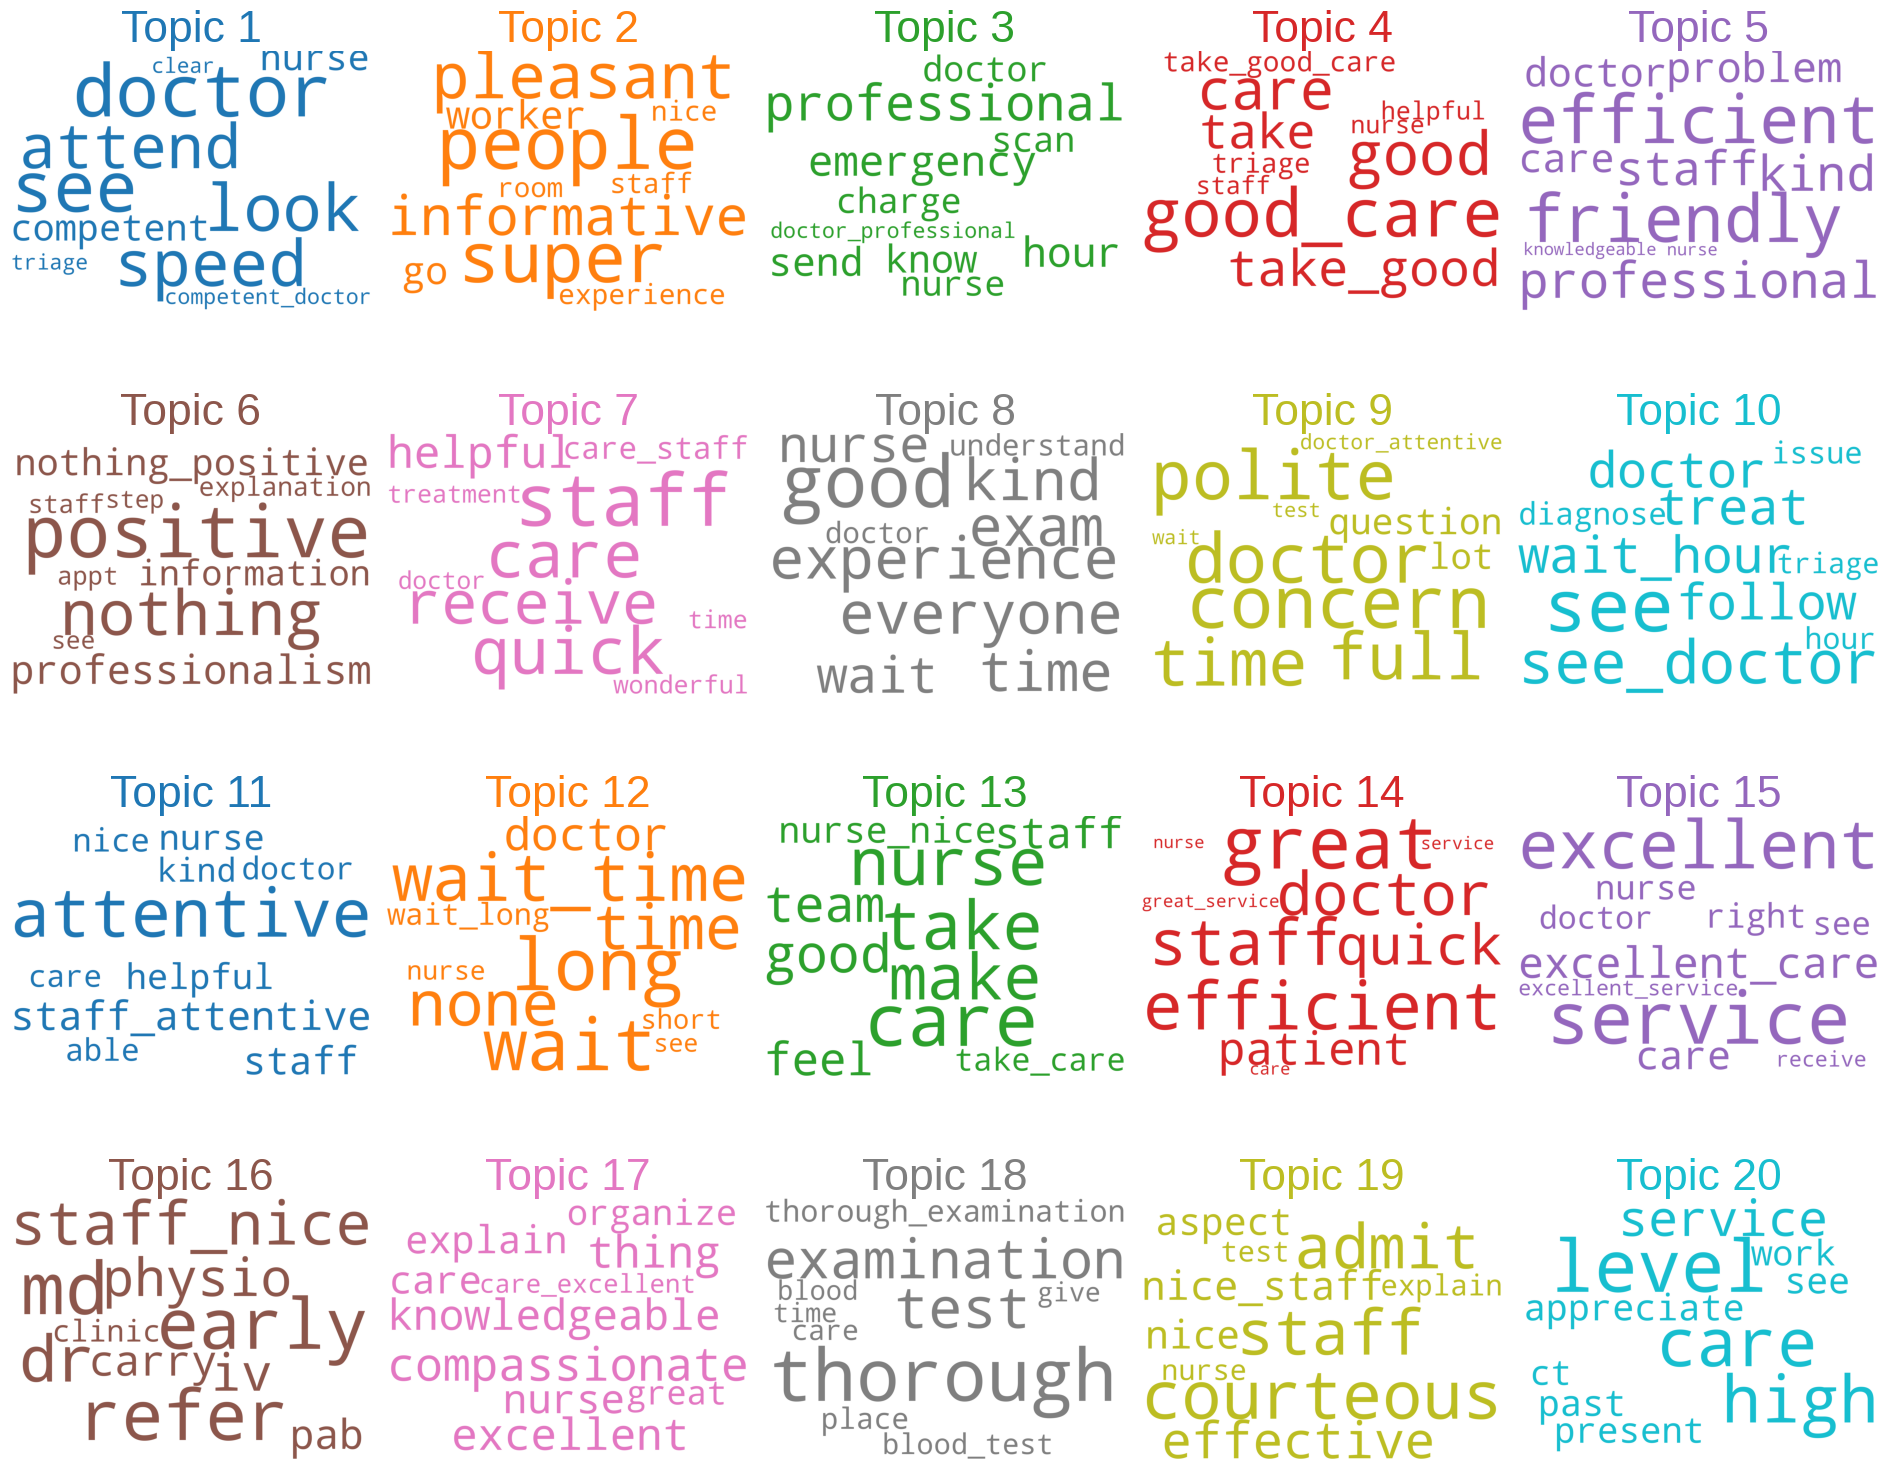

In [19]:
plot_cloud_by_topic(topic_cloud_df, n_topics=20)

### 13.3 Feedback Length Distribution

In [ ]:
def plot_word_count(topicScoresDf, n_topics=20):
    """Plot word count distribution across all reviews."""
    topic_df   = topicScoresDf.limit(5000).toPandas()
    review_lens = topic_df.wordCount

    plt.figure(figsize=(n_topics * 0.95, n_topics - 4))
    counts, bins, patches = plt.hist(review_lens, bins=50, color="navy", alpha=0.7)

    for count, bin_left, bin_right in zip(counts[:16], bins[:16], bins[1:16]):
        if count > 0:
            plt.text(
                (bin_left + bin_right) / 2,
                count,
                str(int(count)),
                ha="center", va="bottom",
                fontsize=10, color="black"
            )
        print(f"no. of {int(count)} reviews for <= {math.ceil((bin_left + bin_right) / 2)} word counts")

    x_pos, y_pos = 40, 800
    plt.text(x_pos, y_pos - 120,  "Mean   : " + str(round(np.mean(review_lens))),            fontsize=16)
    plt.text(x_pos, y_pos - 180,  "Median : " + str(round(np.median(review_lens))),          fontsize=16)
    plt.text(x_pos, y_pos - 240,  "Stdev   : " + str(round(np.std(review_lens))),            fontsize=16)
    plt.text(x_pos, y_pos - 300,  "1%ile    : " + str(round(np.quantile(review_lens, 0.01))),fontsize=16)
    plt.text(x_pos, y_pos - 360,  "99%ile  : " + str(round(np.quantile(review_lens, 0.99))),fontsize=16)
    plt.gca().set(xlim=(0, 100), ylabel="Number of Reviews", xlabel="Review Word Count")
    plt.title("Distribution of Review Word Counts", fontsize=48)
    plt.tight_layout()
    plt.show()

no. of 120 reviews for <= 2 word counts
no. of 344 reviews for <= 2 word counts
no. of 0 reviews for <= 3 word counts
no. of 643 reviews for <= 4 word counts
no. of 0 reviews for <= 4 word counts
no. of 664 reviews for <= 5 word counts
no. of 545 reviews for <= 5 word counts
no. of 0 reviews for <= 6 word counts
no. of 515 reviews for <= 6 word counts
no. of 0 reviews for <= 7 word counts
no. of 343 reviews for <= 8 word counts
no. of 0 reviews for <= 8 word counts
no. of 316 reviews for <= 9 word counts
no. of 205 reviews for <= 9 word counts
no. of 0 reviews for <= 10 word counts


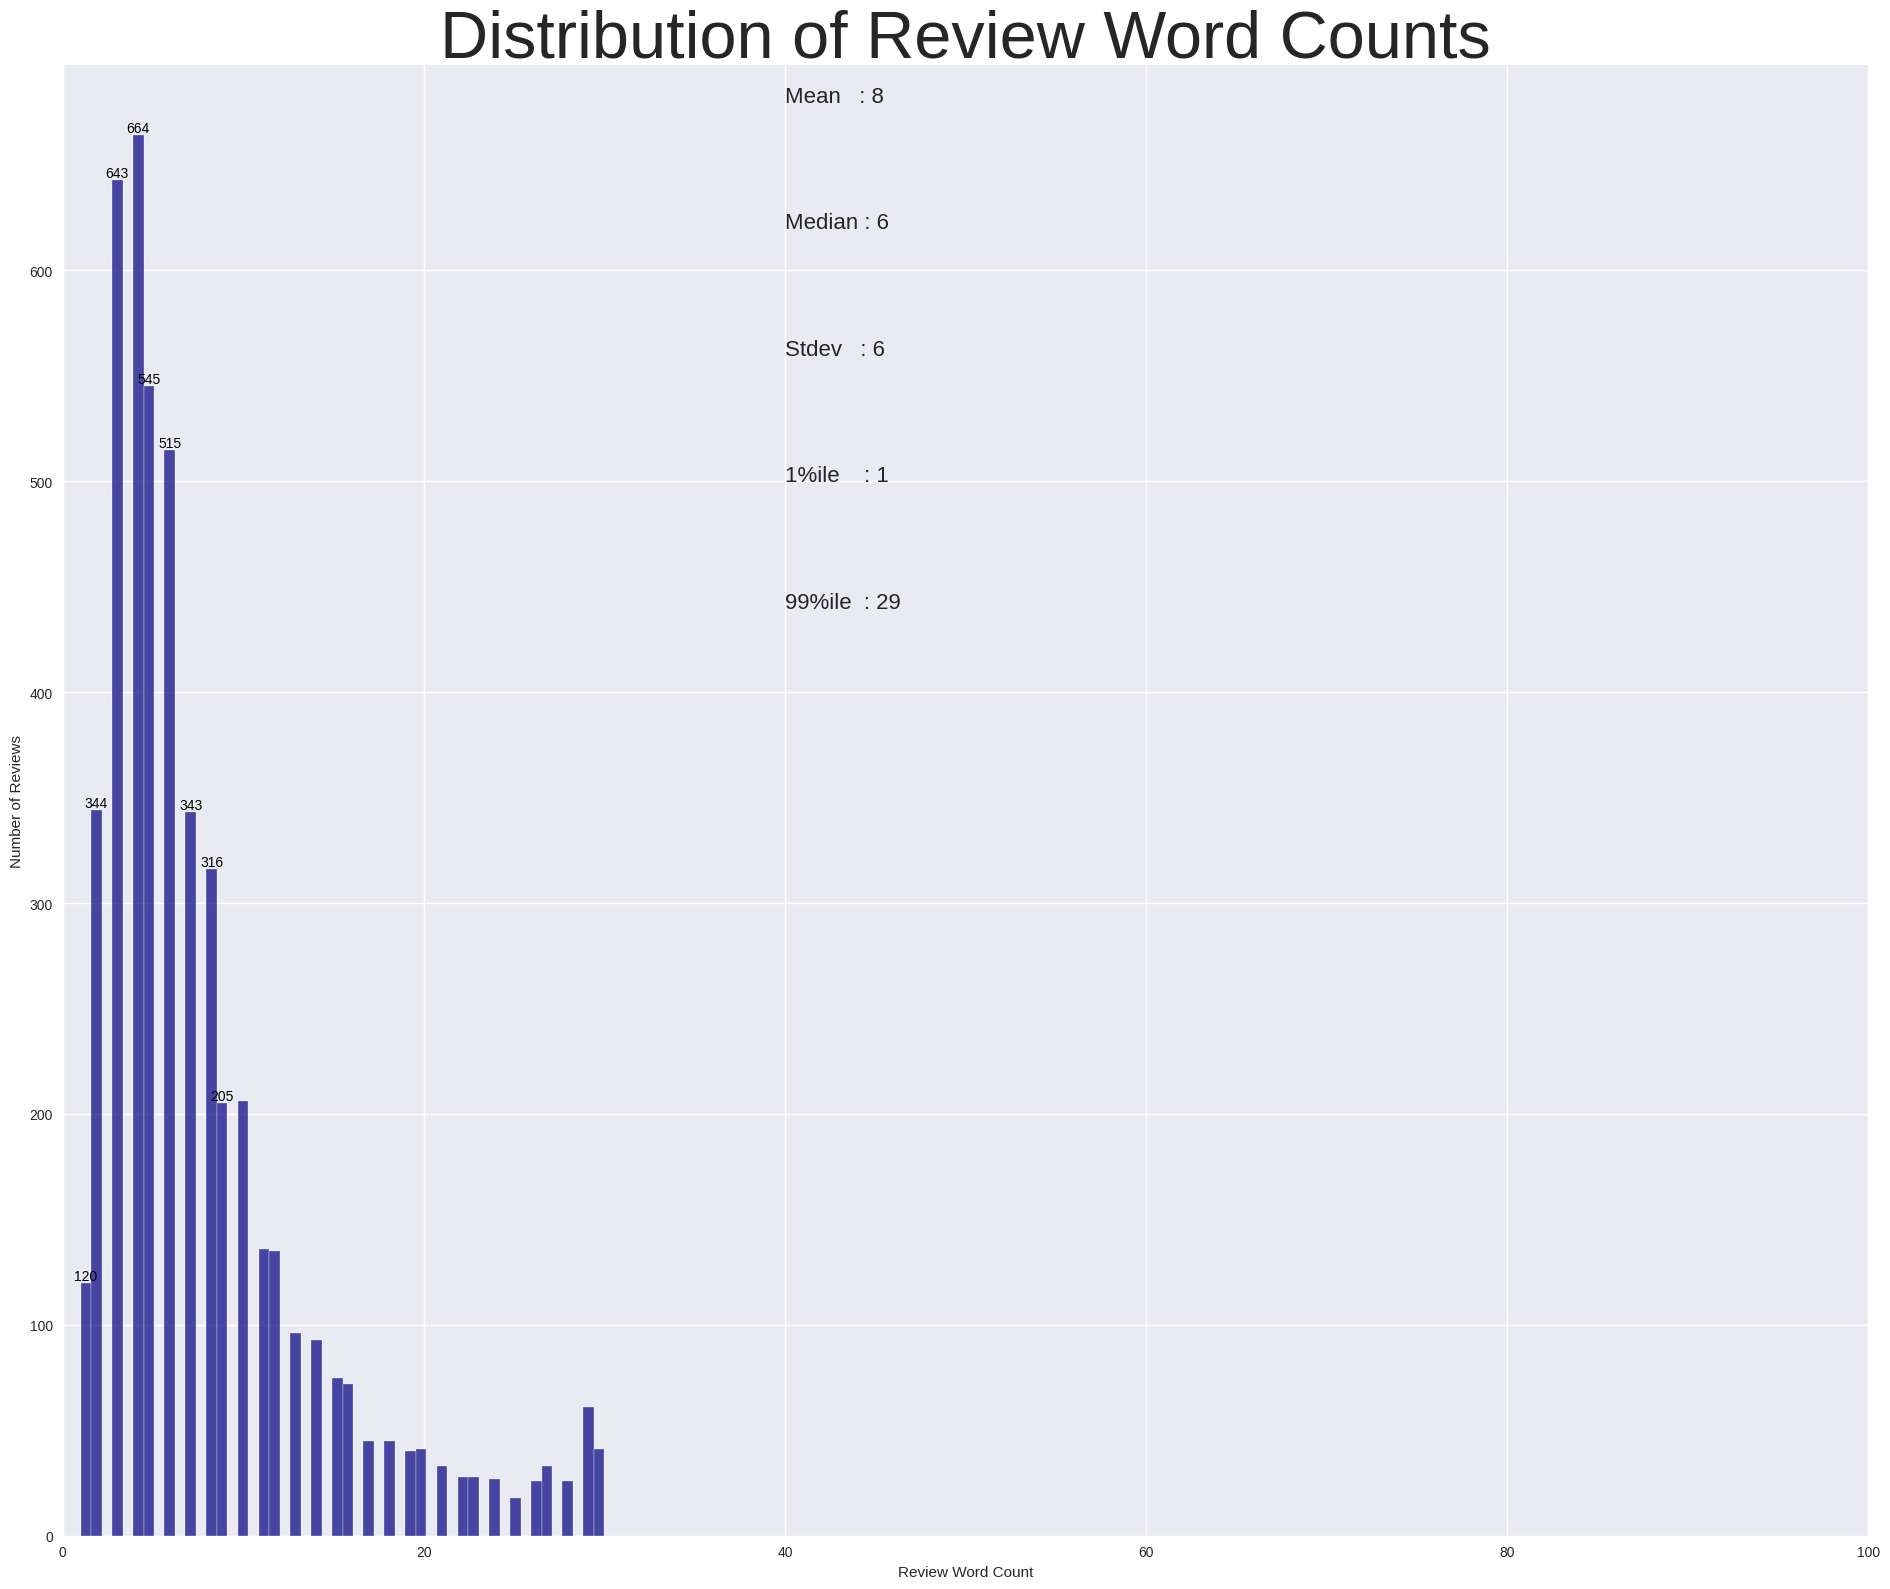

In [23]:
plot_word_count(topic_scores_with_counts_df)

### 13.4 Feedback Length by Topic

In [24]:
def plot_word_count_by_topic(topicScoresDf, n_topics=20):
    """Plot distribution of word count per LDA topic."""
    topic_df = topicScoresDf.limit(5000).toPandas()
    fig, axes = plt.subplots(
        4, int(n_topics / 4),
        figsize=(n_topics * 0.85, n_topics - 4),
        sharex=True, sharey=True,
    )
    for i, ax in enumerate(axes.flatten()):
        topic_df_sub = topic_df.loc[topic_df.topicNo == i, :]
        review_lens  = topic_df_sub.wordCount
        counts, bin_edges, patches = ax.hist(review_lens, bins=25, color=cols[i])
        ax.tick_params(axis="y", labelcolor=cols[i], color=cols[i])
        sns.kdeplot(review_lens, color="black", shade=False, ax=ax.twinx())
        ax.set(xlim=(0, 50), xlabel="Review Word Count")
        ax.set_ylabel("Number of Reviews", color=cols[i])
        ax.set_title(
            f"Topic {i + 1}, total word counts: {math.ceil(np.sum(counts * np.diff(bin_edges)))}",
            fontdict=dict(size=12, color=cols[i])
        )
    fig.tight_layout()
    fig.subplots_adjust(top=0.90)
    fig.suptitle("Distribution of Review Word Counts by LDA Topic", fontsize=32)
    plt.show()

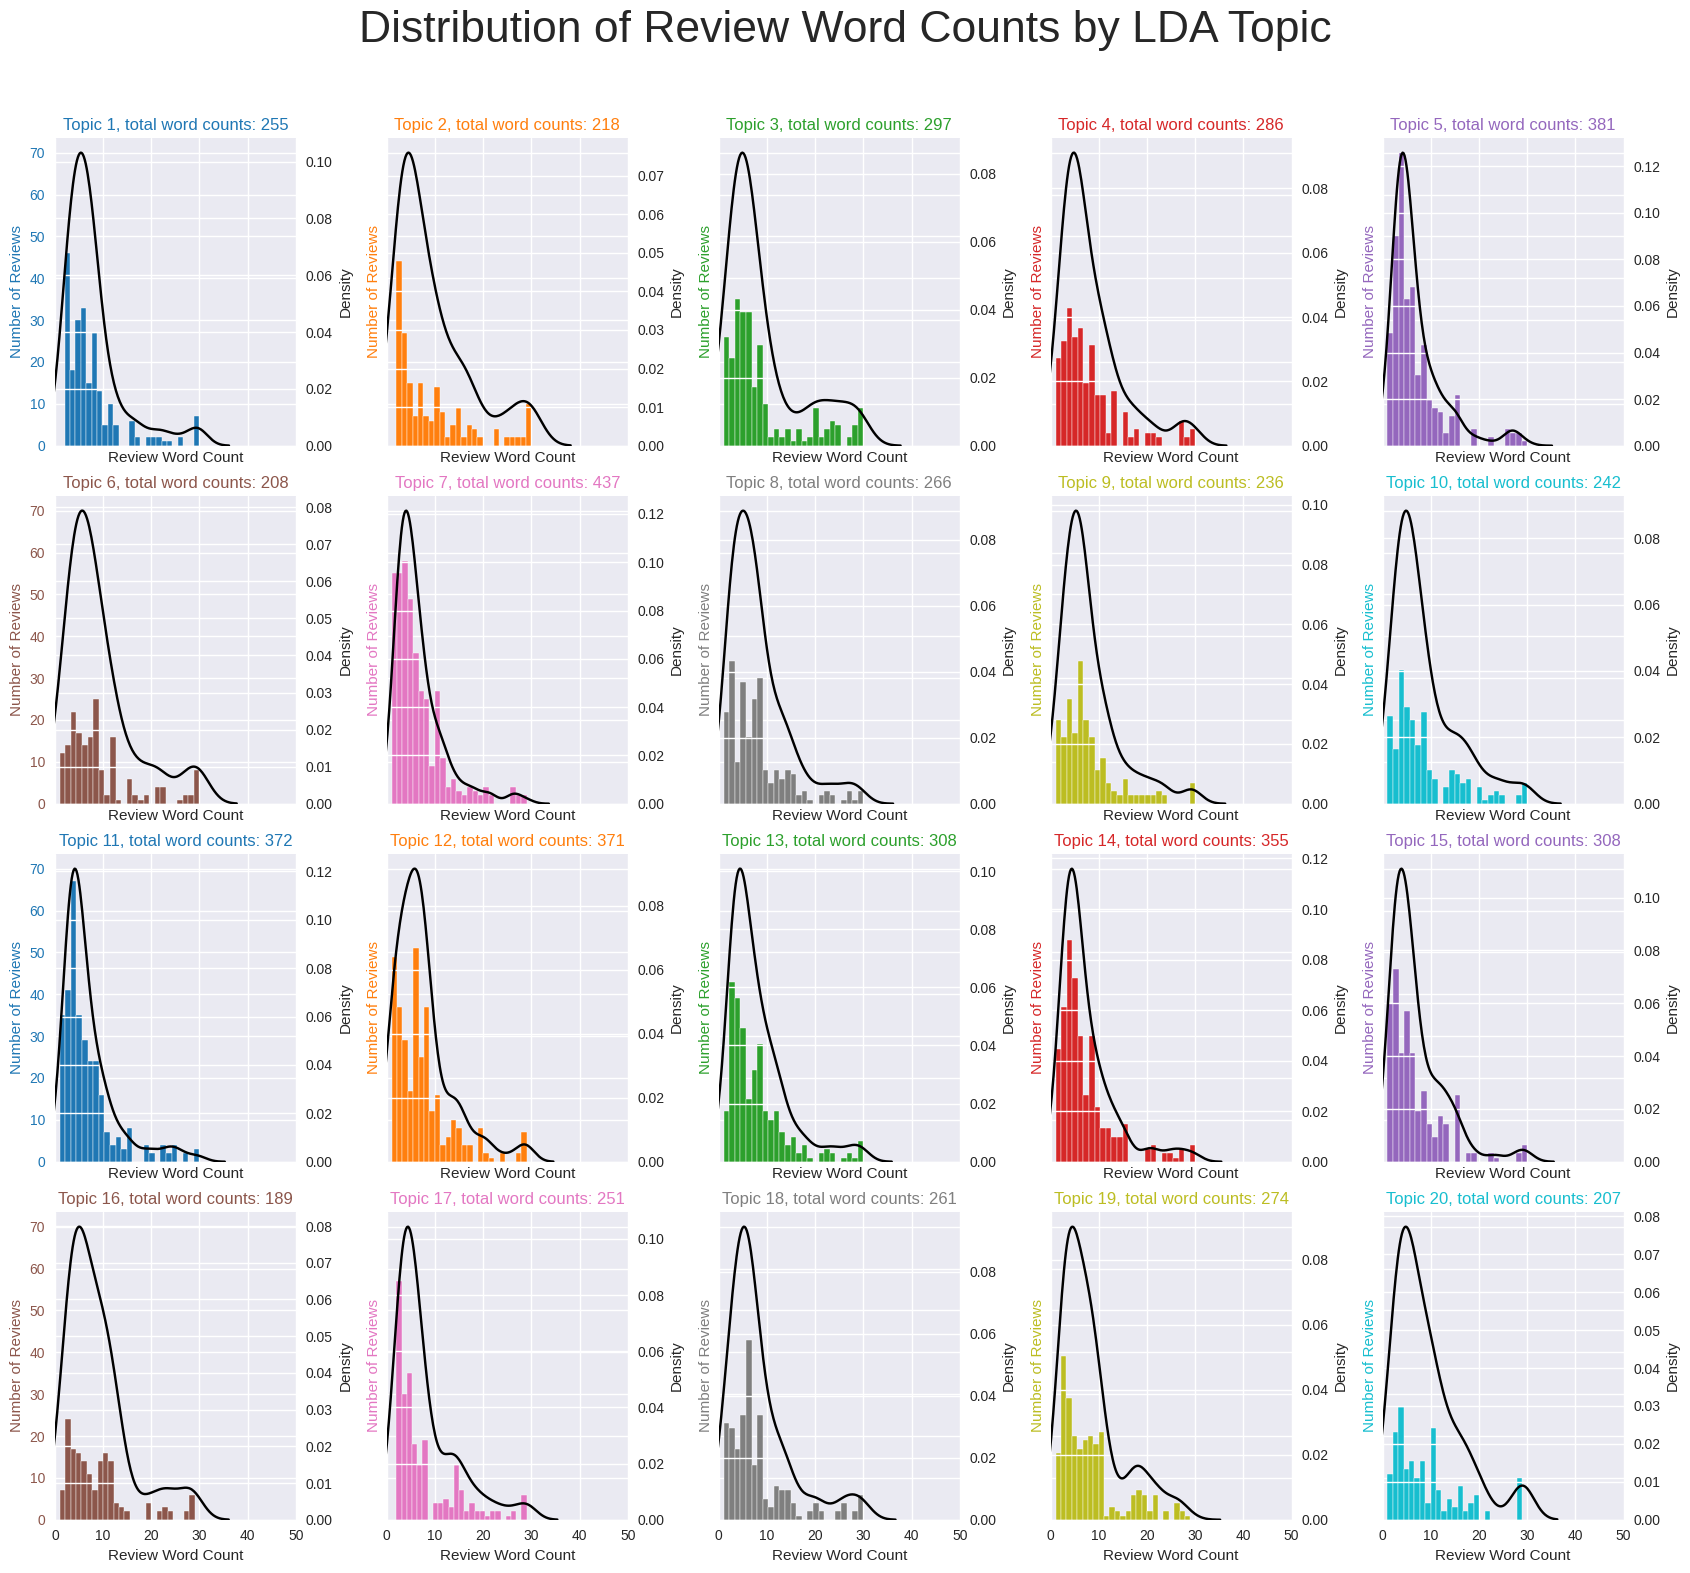

In [25]:
plot_word_count_by_topic(topic_scores_with_counts_df, n_topics=20)